# 0. Configuration

In [32]:
# data load
from pathlib import Path # help with folder and file path 

# dataframe
import pandas as pd
import numpy as np
from functools import reduce

# data visualization
import matplotlib.pyplot as plt

# 1. Read all files

In [33]:
# read files from datasets folder 

def read_df(folder_name):
    ## path object pointing to datasets folder
    folder = Path("datasets") / str(folder_name)

    ## find all files ending in .csv 
    files = list(folder.glob("*.csv")) # glob: method to find files that match pattern 
    ## create list of dataframes for every file 
    dfs = [pd.read_csv(file) for file in files]

    # read each csv to dataframe by taking a list of things and combining into one final

    folder_df = reduce(
        lambda left,right: pd.merge(left,right,on="consumer_id",how="inner"),
        dfs
    ) # drop the first column which is just an index

    return folder_df



## 1a. User Data

In [34]:
# load user data 
users_df = read_df("user")

In [35]:
# see user data
users_df.head(10)

,consumer_id,is_fraudulent,latest_changed_password,max_item_count,days_since_first_transaction,email_address_age_days,email_domain_label,email_domain_tld_label,email_username_length,num_unique_delivery_addresses,latest_delivery_address_name_length,latest_delivery_address_region_label,latest_delivery_address_fraction_vowels
0,1,0,False,2.0,64.653928,51.660825,458.0,17.0,7.0,1.0,16.0,33.0,0.260737
1,2,0,False,1.0,314.989689,255.116569,386.0,17.0,8.0,1.0,14.0,23.0,0.234356
2,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,False,1.0,963.831359,1354.169959,386.0,17.0,9.0,1.0,23.0,11.0,0.438467
4,5,0,False,NaN,NaN,312.916492,386.0,17.0,20.0,NaN,12.0,35.0,0.395141
5,7,0,False,1.0,314.989689,283.147952,1098.0,61.0,13.0,1.0,15.0,15.0,0.359032
6,8,0,False,1.0,1609.408568,1766.505844,386.0,17.0,9.0,1.0,11.0,5.0,0.157338
7,9,0,NaN,NaN,NaN,0.000000,386.0,17.0,14.0,NaN,NaN,NaN,NaN
8,10,0,False,1.0,920.464554,1110.347143,386.0,17.0,10.0,1.0,11.0,5.0,0.398175
9,11,0,NaN,1.0,195.541301,259.899353,1100.0,17.0,11.0,1.0,18.0,5.0,0.326991


In [36]:
# see data types
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16485 entries, 0 to 16484
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   consumer_id                              16485 non-null  int64  
 1   is_fraudulent                            16485 non-null  int64  
 2   latest_changed_password                  11948 non-null  object 
 3   max_item_count                           13274 non-null  float64
 4   days_since_first_transaction             13203 non-null  float64
 5   email_address_age_days                   14426 non-null  float64
 6   email_domain_label                       14426 non-null  float64
 7   email_domain_tld_label                   14426 non-null  float64
 8   email_username_length                    14426 non-null  float64
 9   num_unique_delivery_addresses            11674 non-null  float64
 10  latest_delivery_address_name_length      14211

## 1b. Item Data

In [37]:
# load item data
item_df = read_df("item")

In [38]:
# see item data
item_df.head(10)

,consumer_id,latest_order_amount_usd,latest_item_category,latest_item_product_title,latest_item_quantity,latest_item_tag_count
0,1,109.667419,NaN,NaN,NaN,NaN
1,2,177.268220,Soup,Thom Kha,1.0,0.0
2,3,NaN,Sides,Mashed Potatoes,1.0,1.0
3,4,144.253218,Fresh Salads,Power Greens & Grain Salad - NEW!,1.0,1.0
4,5,NaN,Specialties,Gordita Supreme®,1.0,1.0
5,7,222.007250,Shareable Sides,Onion Rings (Sack),1.0,1.0
6,8,90.645562,Sides,Falafel Side,1.0,1.0
7,9,NaN,NaN,NaN,NaN,NaN
8,10,100.974140,Entrees,Burrito Bowl,1.0,1.0
9,11,192.749328,Poultry & Seafood,Boneless Chicken Kabob,1.0,1.0


In [39]:
item_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16485 entries, 0 to 16484
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   consumer_id                16485 non-null  int64  
 1   latest_order_amount_usd    13273 non-null  float64
 2   latest_item_category       14427 non-null  object 
 3   latest_item_product_title  14427 non-null  object 
 4   latest_item_quantity       14427 non-null  float64
 5   latest_item_tag_count      14427 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 772.9+ KB


## 1c. Activity Data

In [40]:
activity_df = read_df("activity")

In [41]:
# see activity data
activity_df.head(10)

,consumer_id,per_week_purchase_total,per_week_unique_ips,per_week_update_account,per_week_payment_method_change,per_day_add_item_to_cart,per_day_transactions,per_day_payment_method_change,per_day_devices_per_user,per_day_purchase_total,per_day_unique_billing_last4,per_month_logout,per_month_page_activity,per_month_transactions
0,1,NaN,1.0,4.0,0.0,NaN,4.0,0.0,1.0,NaN,1.0,NaN,NaN,1.486624
1,2,24.73,1.0,NaN,0.0,NaN,1.0,0.0,1.0,24.73,NaN,NaN,NaN,4.483389
2,3,NaN,1.0,NaN,0.0,4.0,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN
3,4,64.21,1.0,NaN,0.0,1.0,NaN,0.0,1.0,0.00,NaN,NaN,1.0,2.056617
4,5,NaN,1.0,1.0,0.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN
5,7,21.96,3.0,4.0,0.0,NaN,3.0,0.0,3.0,21.96,1.0,NaN,NaN,4.483389
6,8,48.02,1.0,NaN,0.0,NaN,1.0,0.0,1.0,48.02,NaN,NaN,1.0,4.483389
7,9,NaN,1.0,NaN,0.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN
8,10,34.73,1.0,NaN,0.0,NaN,1.0,0.0,1.0,34.73,1.0,NaN,NaN,0.111225
9,11,31.85,1.0,NaN,0.0,NaN,1.0,0.0,1.0,31.85,NaN,NaN,NaN,7.369085


In [42]:
activity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16485 entries, 0 to 16484
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   consumer_id                     16485 non-null  int64  
 1   per_week_purchase_total         10843 non-null  float64
 2   per_week_unique_ips             16485 non-null  float64
 3   per_week_update_account         8048 non-null   float64
 4   per_week_payment_method_change  16485 non-null  float64
 5   per_day_add_item_to_cart        3863 non-null   float64
 6   per_day_transactions            8978 non-null   float64
 7   per_day_payment_method_change   16485 non-null  float64
 8   per_day_devices_per_user        16474 non-null  float64
 9   per_day_purchase_total          10843 non-null  float64
 10  per_day_unique_billing_last4    6825 non-null   float64
 11  per_month_logout                580 non-null    float64
 12  per_month_page_activity         

# 2. Distribution Check

## 2a. Simple Distribution

In [43]:
# see users data summary statistics
users_df.describe().T

,count,mean,std,min,25%,50%,75%,max
consumer_id,16485.0,10331.000667,5960.459638,1.000000,5160.000000,10350.000000,15465.000000,20651.000000
is_fraudulent,16485.0,0.065757,0.247864,0.000000,0.000000,0.000000,0.000000,1.000000
max_item_count,13274.0,1.512430,1.491139,1.000000,1.000000,1.000000,2.000000,50.000000
days_since_first_transaction,13203.0,412.448007,313.353900,0.178640,250.389598,314.989689,497.100639,2160.582356
email_address_age_days,14426.0,439.519107,431.582203,0.000000,124.043953,281.185836,675.078291,3872.999039
email_domain_label,14426.0,508.775475,293.949005,0.000000,386.000000,386.000000,575.000000,1128.000000
email_domain_tld_label,14426.0,19.223901,7.540011,0.000000,17.000000,17.000000,17.000000,64.000000
email_username_length,14426.0,11.233537,3.349955,1.000000,9.000000,11.000000,13.000000,31.000000
num_unique_delivery_addresses,11674.0,1.273856,0.721794,1.000000,1.000000,1.000000,1.000000,14.000000
latest_delivery_address_name_length,14211.0,12.990571,3.127377,1.000000,11.000000,13.000000,15.000000,82.000000


1. is_fraudulent
- Key Statistics: Fraud ratio is about 6.5%
- Key Learnings: Indicates Class Imbalance
- Next Steps: Sampling, and modeling process

2. max_item_count,  email_address_age_days, num_unique_delivery_addresses, latest_delivery_address_name_length
- Key Statistics: Right skewed
- Key Learnings: Outliers exist at the upper limit
- Next Steps: Data Cleaning, check distribution again for fraudulent vs non fraudulent 

3. email_domain_label, email_domain_tld_label
- Key Learnings: This is nominal categorical values. Values don't seem to indicate real values
- Next Steps: Data Cleaning

In [44]:
item_df.describe().T

,count,mean,std,min,25%,50%,75%,max
consumer_id,16485.0,10331.000667,5960.459638,1.000000,5160.000000,10350.000000,15465.000000,20651.000000
latest_order_amount_usd,13273.0,113.704311,113.618403,0.011521,72.636183,109.667419,111.192081,2985.892208
latest_item_quantity,14427.0,1.141540,0.783290,1.000000,1.000000,1.000000,1.000000,30.000000
latest_item_tag_count,14427.0,0.960075,0.195790,0.000000,1.000000,1.000000,1.000000,1.000000


1. latest_order_amount_usd
- Key Statistics: Right skewed
- Key Learnings: Some values are less than $1, may need to replace values.
- Next Steps: Data Cleaning, check distribution again for fraudulent vs non fraudulent 

2. latest_item_quantity
- Key Statistics: only values from 75% to max are greater than 1 
- Key Learnings: At least one item is ordered 
- Next Steps: Data Cleaning, check distribution again for fraudulent vs non fraudulent 


In [45]:
activity_df.describe().T

,count,mean,std,min,25%,50%,75%,max
consumer_id,16485.0,10331.000667,5960.459638,1.000000,5160.00000,10350.000000,15465.000000,20651.000000
per_week_purchase_total,10843.0,46.812499,139.511627,0.000000,1.95000,24.890000,49.270000,7606.630000
per_week_unique_ips,16485.0,1.360024,0.789178,1.000000,1.00000,1.000000,1.000000,11.000000
per_week_update_account,8048.0,3.610462,4.271304,1.000000,1.00000,2.000000,4.000000,91.000000
per_week_payment_method_change,16485.0,0.395814,1.817877,0.000000,0.00000,0.000000,0.000000,46.000000
per_day_add_item_to_cart,3863.0,7.563034,11.682184,1.000000,2.00000,3.000000,6.000000,57.000000
per_day_transactions,8978.0,1.973379,2.559586,1.000000,1.00000,1.000000,2.000000,33.000000
per_day_payment_method_change,16485.0,0.248893,1.298081,0.000000,0.00000,0.000000,0.000000,46.000000
per_day_devices_per_user,16474.0,1.222836,0.561463,1.000000,1.00000,1.000000,1.000000,9.000000
per_day_purchase_total,10843.0,31.424978,131.251590,0.000000,0.00000,17.980000,31.810000,7606.630000


1. payment_method_change, per_day_payment_method_change 
- Key Statistics: only values above 75% to max are 46
- Key Learning: customers that change payment method frequently are rare
- Next Steps: Check distribution again for fradulent  vs non fradulent (likely that these are fraud)

2. per_week_purchase_total, per_day_purchase_total, per_month_transactions
- Key Statistics: highly right skewed
- Key Learning: these customers may be fradulent or may be high-value customers

3. per_month_logout, per_day_unique_billing_last4
- Key Statistics: values between 0 to 75% are just 1 and above 75% are high
- Key Learning: These may indicate fraud



In [46]:
# Combine all data to one df
names = [users_df, item_df, activity_df]

# combine to one df
fraud_df = reduce(lambda left,right: pd.merge(left,right,on='consumer_id',how='inner'), names)

In [47]:
# see data
fraud_df.head(10)

,consumer_id,is_fraudulent,latest_changed_password,max_item_count,days_since_first_transaction,email_address_age_days,email_domain_label,email_domain_tld_label,email_username_length,num_unique_delivery_addresses,...,per_week_payment_method_change,per_day_add_item_to_cart,per_day_transactions,per_day_payment_method_change,per_day_devices_per_user,per_day_purchase_total,per_day_unique_billing_last4,per_month_logout,per_month_page_activity,per_month_transactions
0,1,0,False,2.0,64.653928,51.660825,458.0,17.0,7.0,1.0,...,0.0,NaN,4.0,0.0,1.0,NaN,1.0,NaN,NaN,1.486624
1,2,0,False,1.0,314.989689,255.116569,386.0,17.0,8.0,1.0,...,0.0,NaN,1.0,0.0,1.0,24.73,NaN,NaN,NaN,4.483389
2,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,4.0,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN
3,4,0,False,1.0,963.831359,1354.169959,386.0,17.0,9.0,1.0,...,0.0,1.0,NaN,0.0,1.0,0.00,NaN,NaN,1.0,2.056617
4,5,0,False,NaN,NaN,312.916492,386.0,17.0,20.0,NaN,...,0.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN
5,7,0,False,1.0,314.989689,283.147952,1098.0,61.0,13.0,1.0,...,0.0,NaN,3.0,0.0,3.0,21.96,1.0,NaN,NaN,4.483389
6,8,0,False,1.0,1609.408568,1766.505844,386.0,17.0,9.0,1.0,...,0.0,NaN,1.0,0.0,1.0,48.02,NaN,NaN,1.0,4.483389
7,9,0,NaN,NaN,NaN,0.000000,386.0,17.0,14.0,NaN,...,0.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN
8,10,0,False,1.0,920.464554,1110.347143,386.0,17.0,10.0,1.0,...,0.0,NaN,1.0,0.0,1.0,34.73,1.0,NaN,NaN,0.111225
9,11,0,NaN,1.0,195.541301,259.899353,1100.0,17.0,11.0,1.0,...,0.0,NaN,1.0,0.0,1.0,31.85,NaN,NaN,NaN,7.369085


## 2b. compare fraud vs non fraud

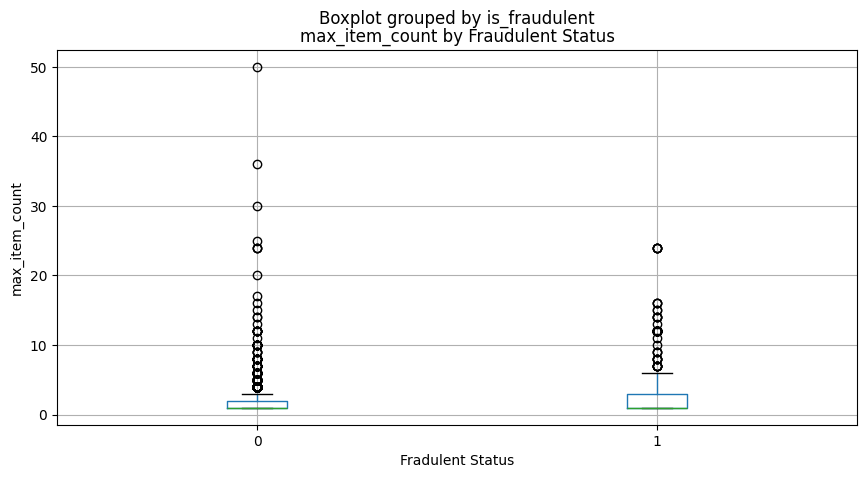

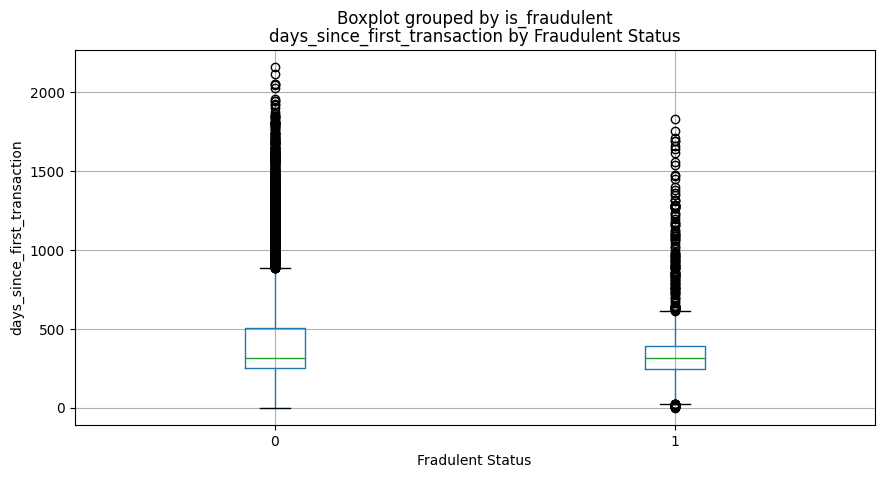

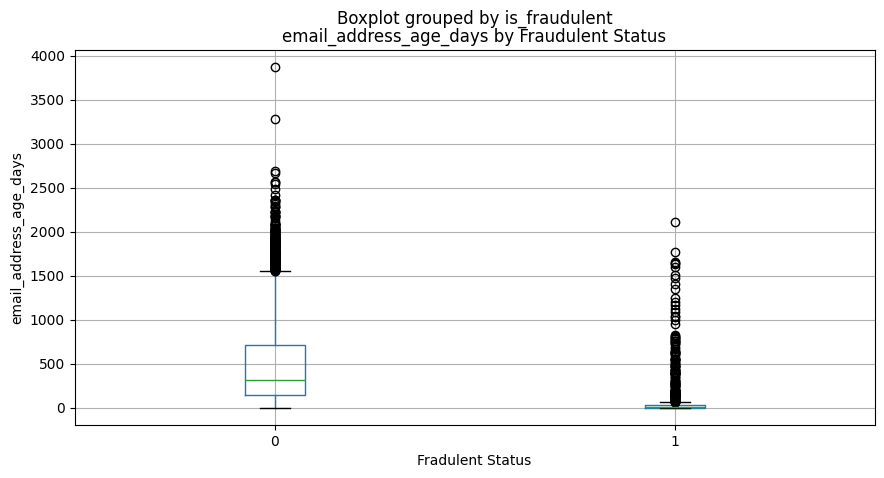

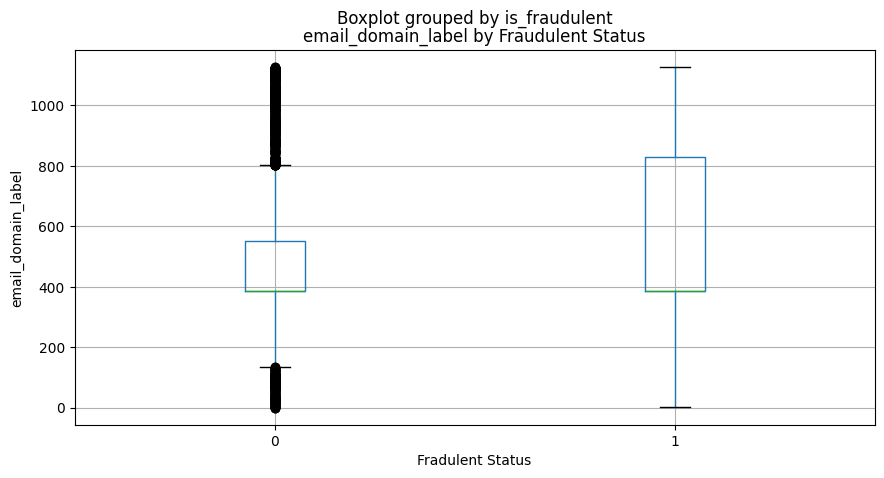

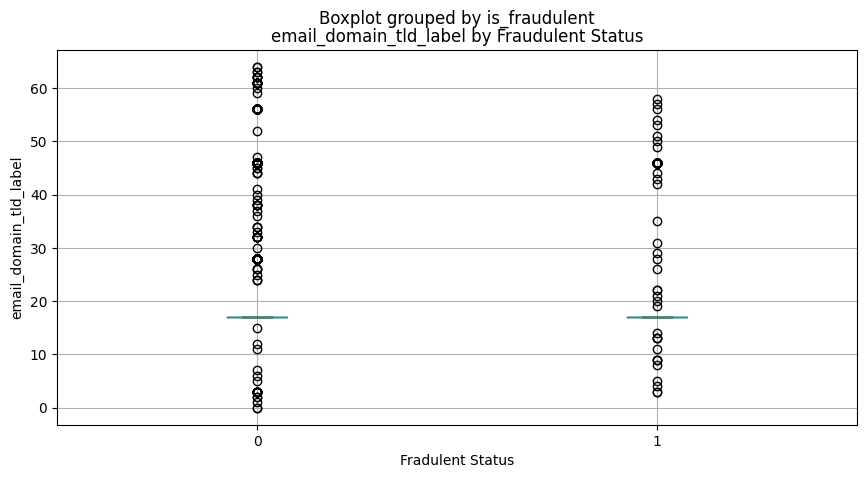

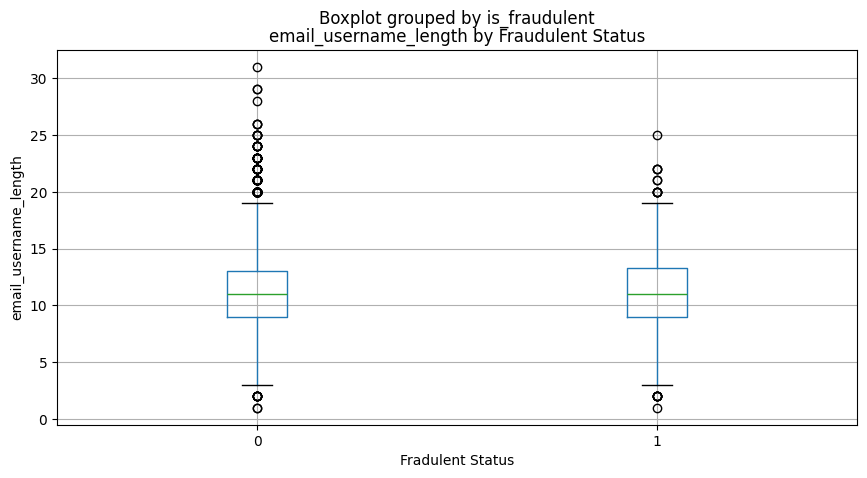

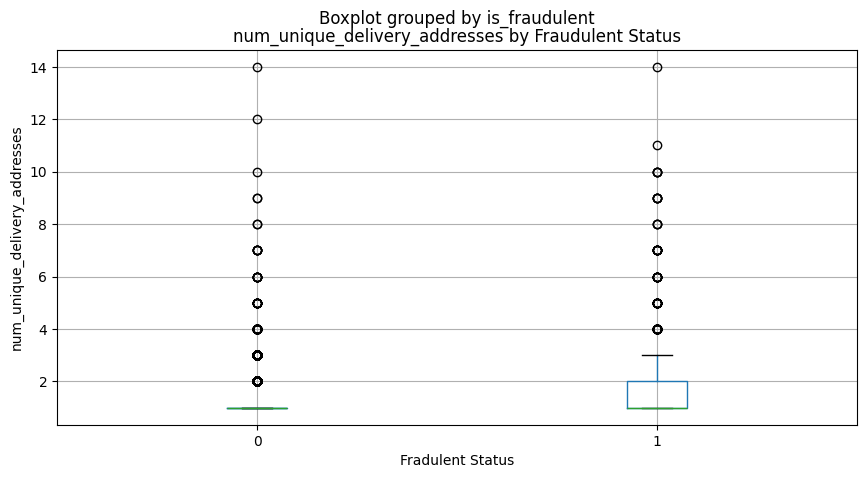

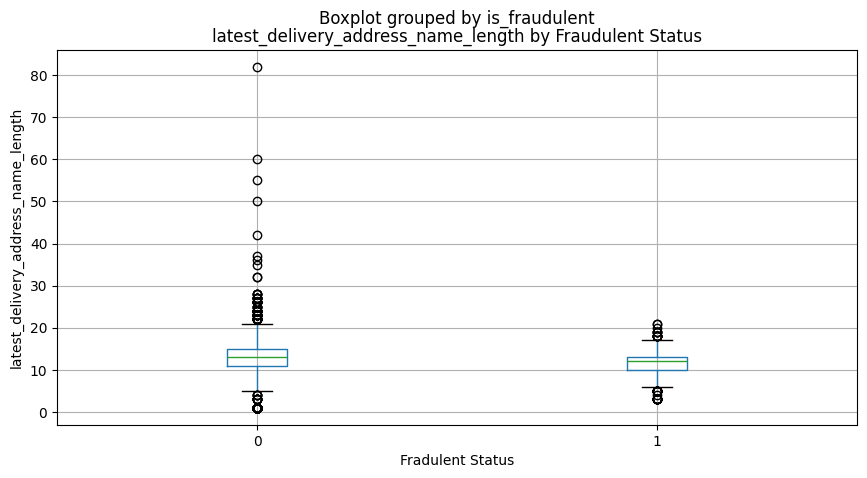

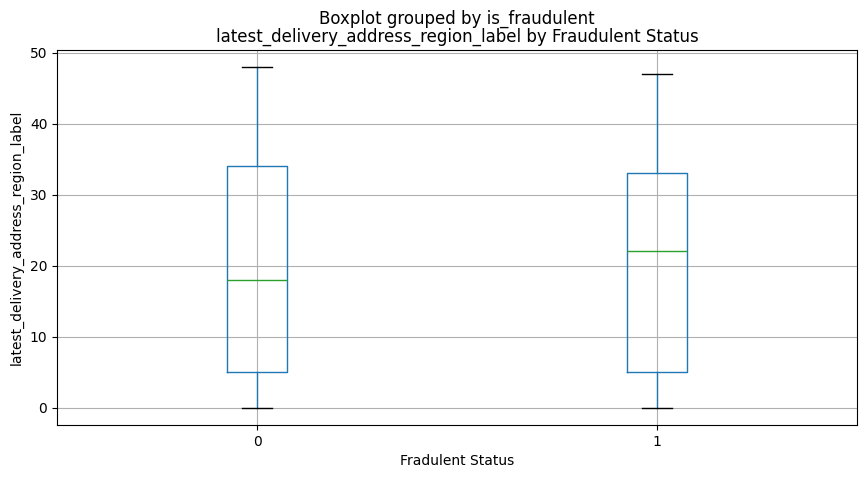

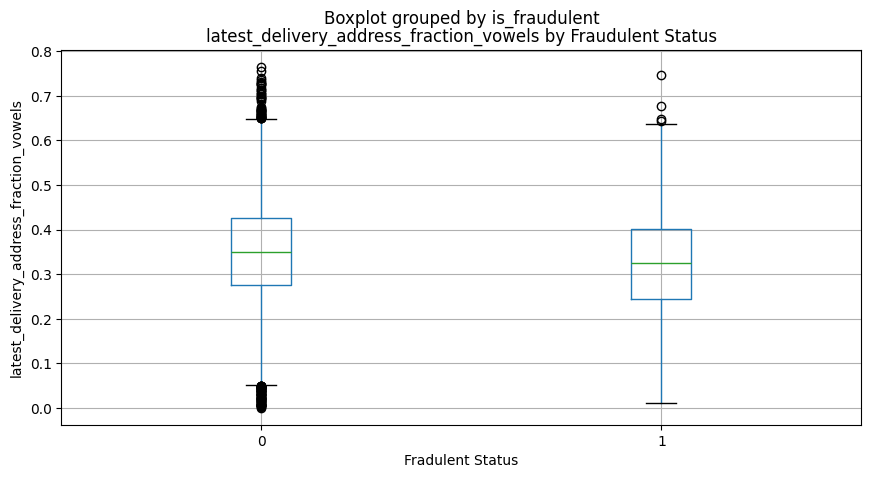

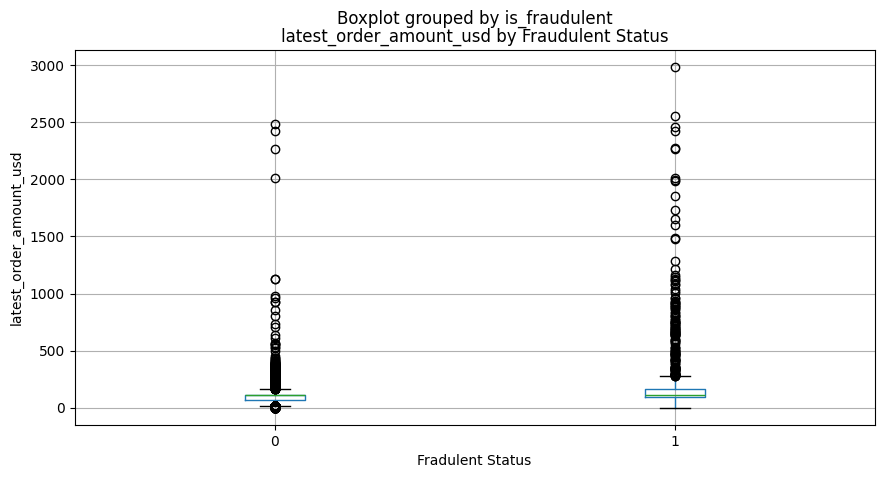

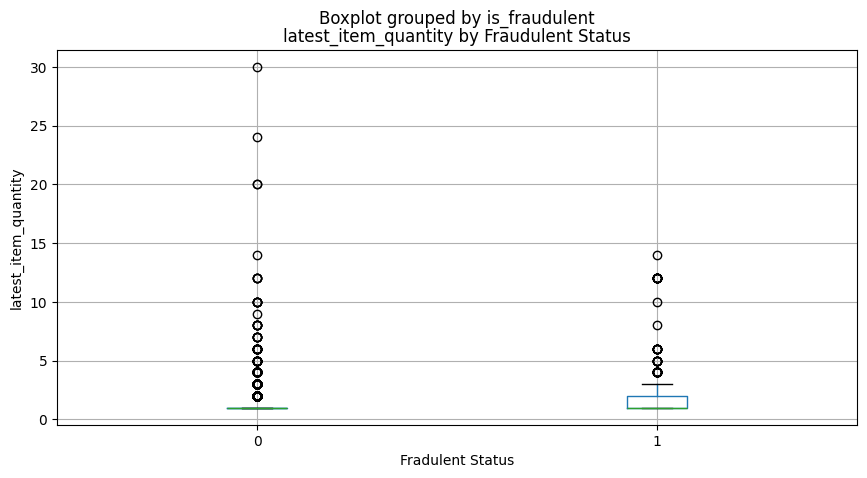

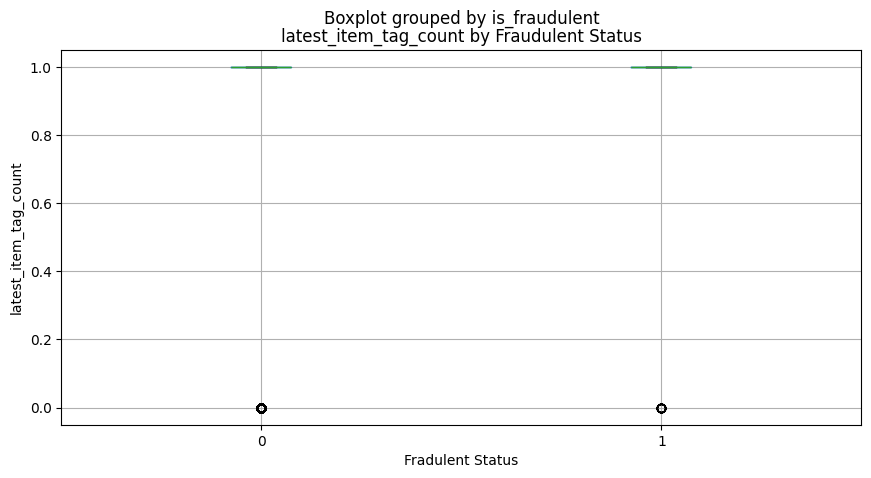

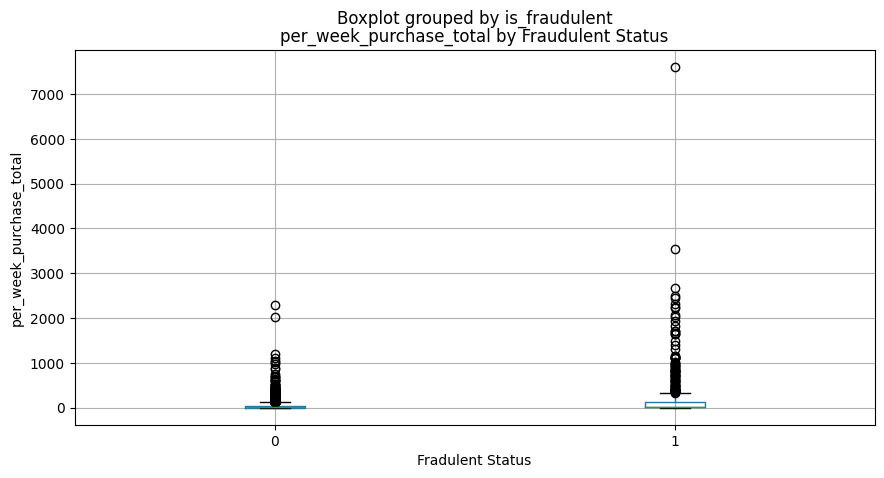

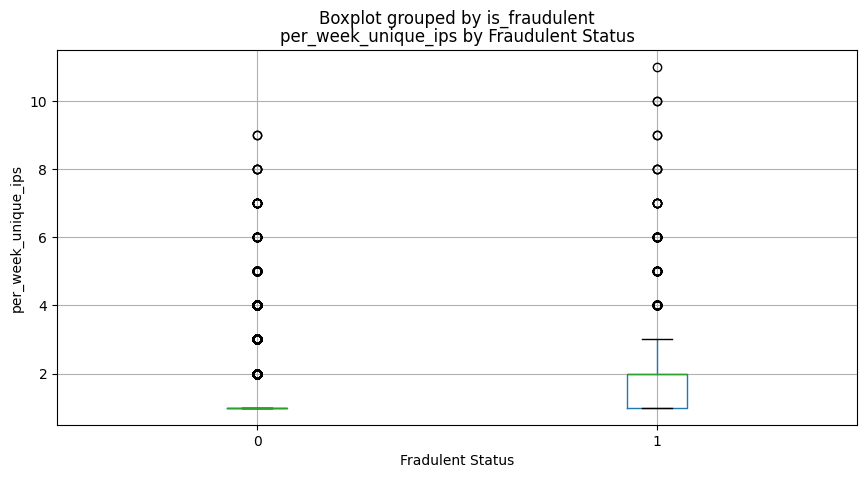

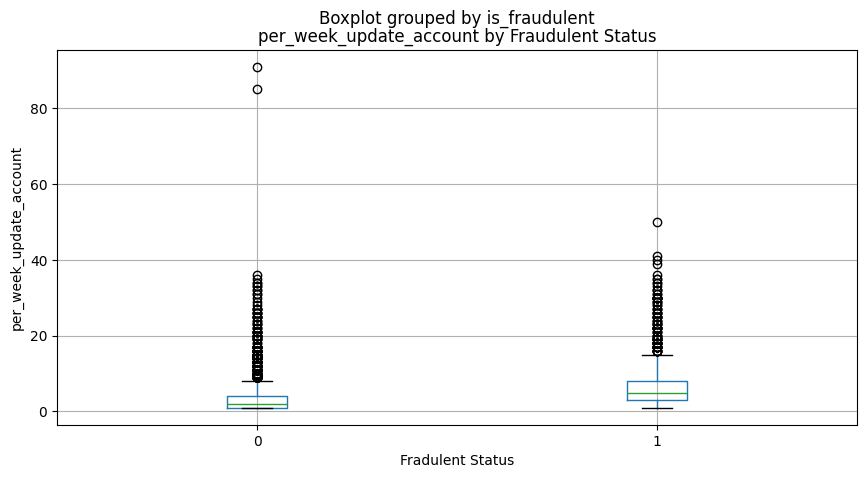

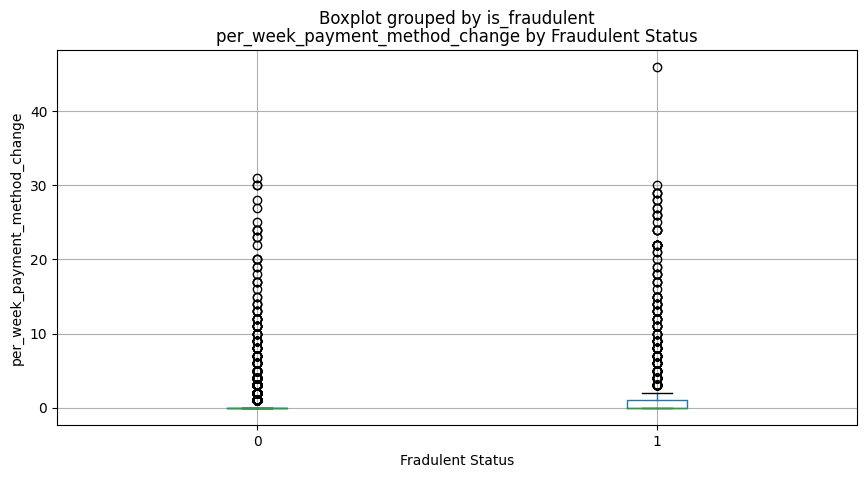

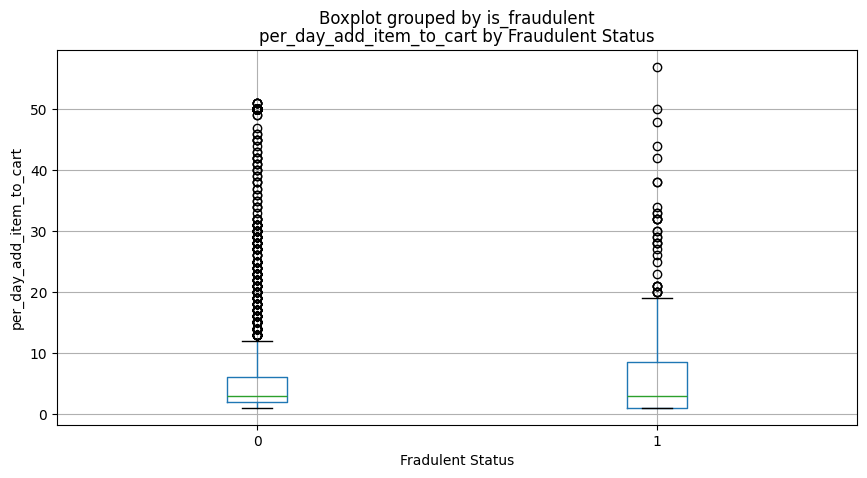

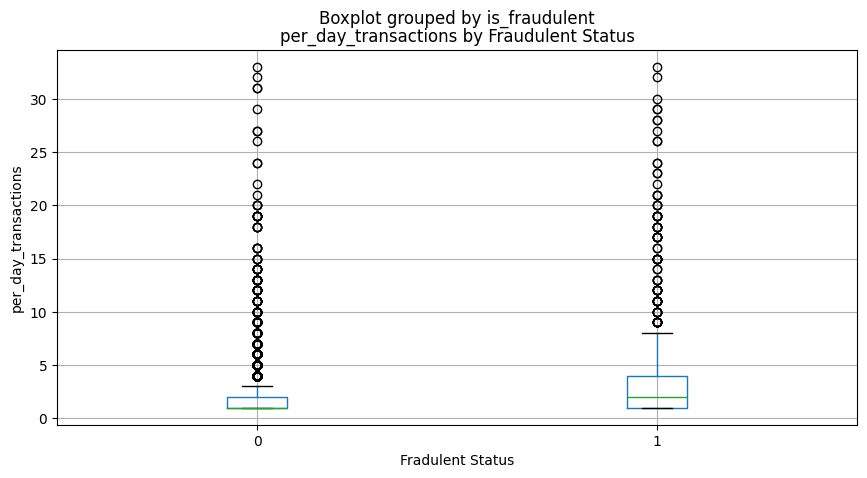

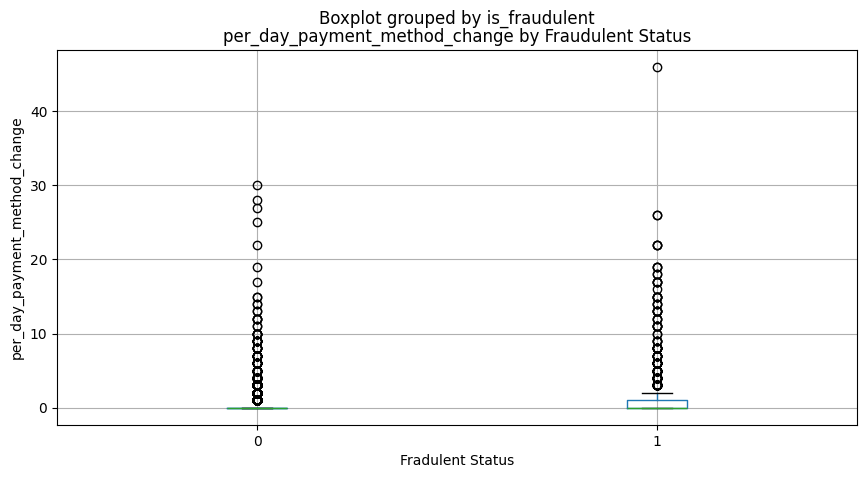

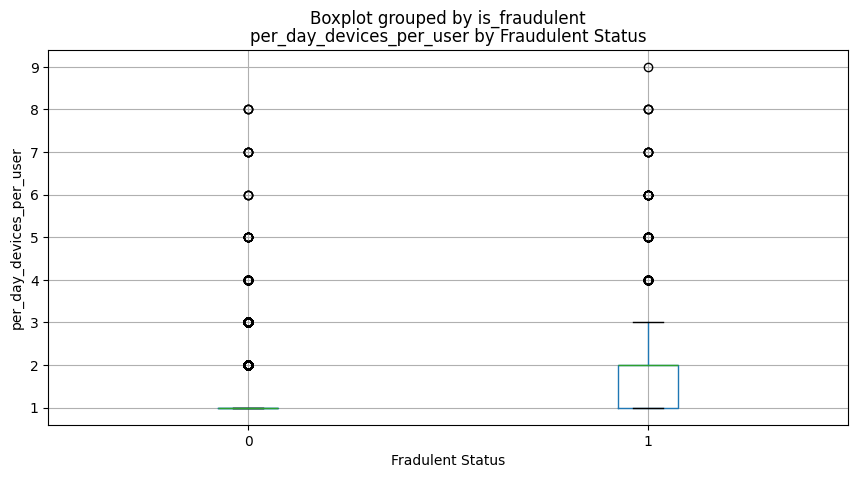

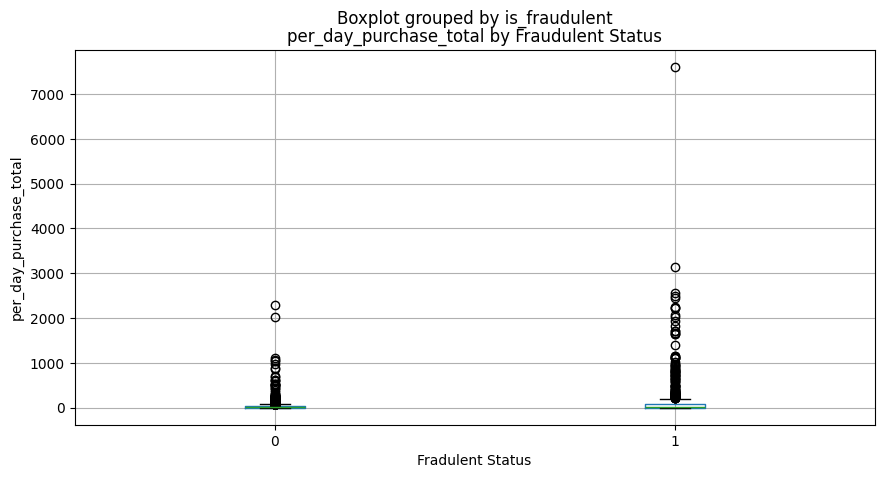

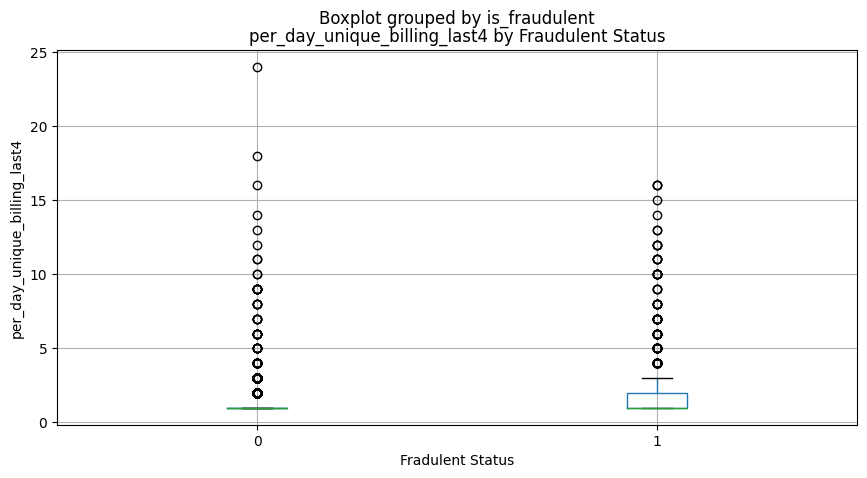

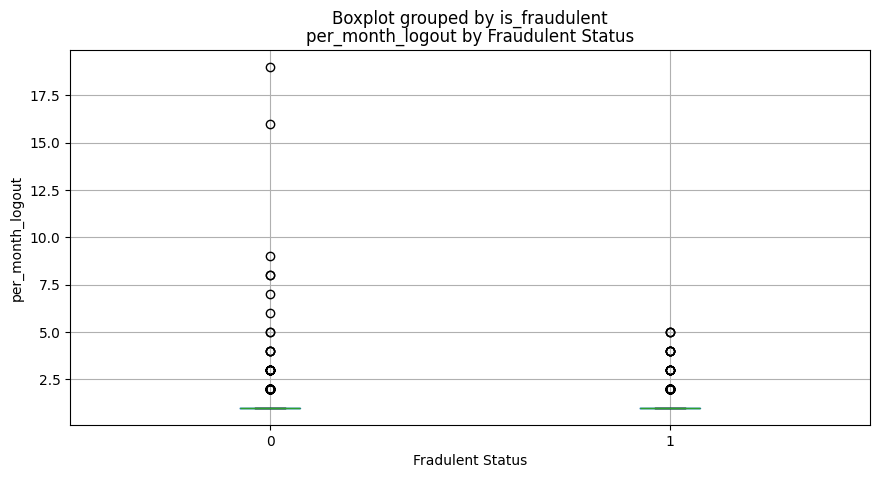

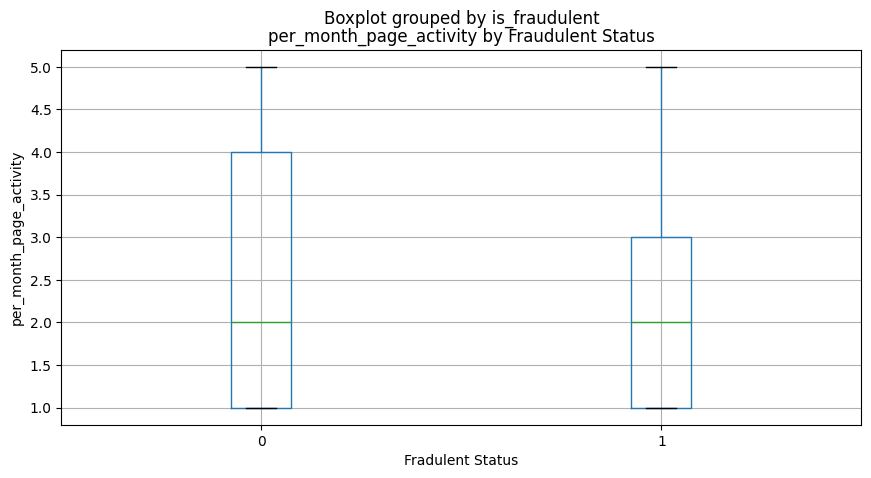

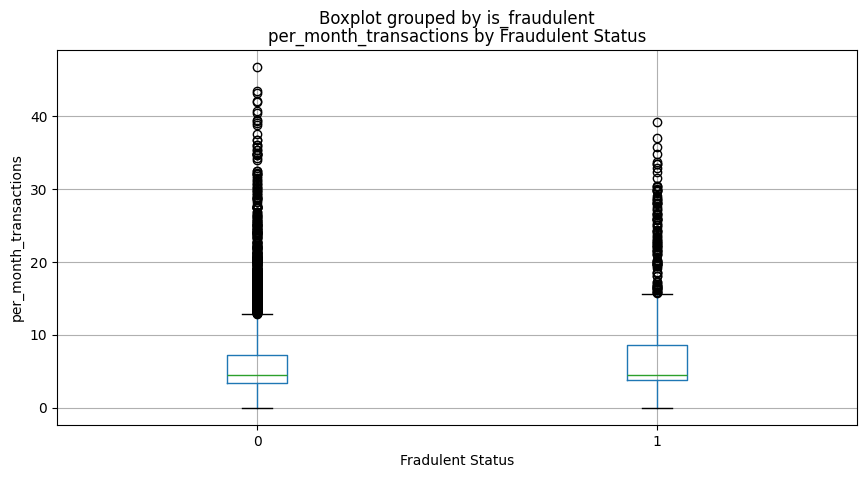

In [48]:
num_col_names = fraud_df.select_dtypes(include=np.number).columns.tolist()
num_col_names = [col for col in num_col_names if col not in ['is_fraudulent','consumer_id']]

for col in num_col_names:
    fraud_df.boxplot(column = col, by='is_fraudulent',figsize=(10,5))
    plt.title(f"{col} by Fraudulent Status")
    plt.xlabel("Fradulent Status")
    plt.ylabel(col)
    plt.show()

Based on the box plots, several features show noticeable distributional differences between the fraudulent and non-fraudulent groups, suggesting they may be useful predictors of fraud.

The variables with the clearest separation are: 

days_since_first_transaction, email_address_age_days, email_domian_label, num_unique_delivery_address, latest_delivery_address_name_length, latest_delivery_address_fraction_vowels, latest_order_amount_usd, per_week_purchase_total, per_week_update_account, per_day_add_item_to_cart, per_day_transactions, per_day_payment_method, per_day_devices_per_user, per_day_purchase_total, per_day_unique_billing_last4

In particular, variables related to transaction history, email characteristics, delivery address behavior, spending patterns, account activity, device usage, and payment behavior show some degree of separation across the two groups. This suggests that these features may carry predictive signal for distinguishing fraudulent from non-fraudulent cases and should be prioritized for further analysis and model development.

In [49]:
# get categorical column  names
categorical_col_names = fraud_df.select_dtypes(include='object').columns.tolist()

In [50]:
categorical_col_names

['latest_changed_password',
 'latest_item_category',
 'latest_item_product_title']

In [51]:
# for categorical column values, impute missing value to 'Missing'
for col in categorical_col_names:
    fraud_df.fillna({col:'Missing'}, inplace=True)

# 3. Data Preparation

## 3a. Data Type

In [52]:
# set categorical columns to category data type
fraud_df[categorical_col_names] = fraud_df[categorical_col_names].astype('category')

## 3b. Missing Values

In [53]:
# see columns with missing values 
fraud_df.isna().sum()

consumer_id                                    0
is_fraudulent                                  0
latest_changed_password                        0
max_item_count                              3211
days_since_first_transaction                3282
email_address_age_days                      2059
email_domain_label                          2059
email_domain_tld_label                      2059
email_username_length                       2059
num_unique_delivery_addresses               4811
latest_delivery_address_name_length         2274
latest_delivery_address_region_label        2274
latest_delivery_address_fraction_vowels     2274
latest_order_amount_usd                     3212
latest_item_category                           0
latest_item_product_title                      0
latest_item_quantity                        2058
latest_item_tag_count                       2058
per_week_purchase_total                     5642
per_week_unique_ips                            0
per_week_update_acco

In [54]:
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16485 entries, 0 to 16484
Data columns (total 31 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   consumer_id                              16485 non-null  int64   
 1   is_fraudulent                            16485 non-null  int64   
 2   latest_changed_password                  16485 non-null  category
 3   max_item_count                           13274 non-null  float64 
 4   days_since_first_transaction             13203 non-null  float64 
 5   email_address_age_days                   14426 non-null  float64 
 6   email_domain_label                       14426 non-null  float64 
 7   email_domain_tld_label                   14426 non-null  float64 
 8   email_username_length                    14426 non-null  float64 
 9   num_unique_delivery_addresses            11674 non-null  float64 
 10  latest_delivery_address_name_lengt

In [55]:
# fill all missing values (only numeric) to -999
# num_col_names are names of numeric columns
fraud_df[num_col_names] =fraud_df[num_col_names].fillna(-999)

fraud_df[categorical_col_names] = fraud_df[categorical_col_names].fillna('Missing')

In [56]:
fraud_df[num_col_names].isna().sum()

max_item_count                             0
days_since_first_transaction               0
email_address_age_days                     0
email_domain_label                         0
email_domain_tld_label                     0
email_username_length                      0
num_unique_delivery_addresses              0
latest_delivery_address_name_length        0
latest_delivery_address_region_label       0
latest_delivery_address_fraction_vowels    0
latest_order_amount_usd                    0
latest_item_quantity                       0
latest_item_tag_count                      0
per_week_purchase_total                    0
per_week_unique_ips                        0
per_week_update_account                    0
per_week_payment_method_change             0
per_day_add_item_to_cart                   0
per_day_transactions                       0
per_day_payment_method_change              0
per_day_devices_per_user                   0
per_day_purchase_total                     0
per_day_un

## 3c. Split Data

The label class (fraud) is imbalanced. 

In [57]:
from sklearn.model_selection import train_test_split

# define features X and target Y
# exclude target (is_fraudulent) and consumer_id 

feature_cols = [col for col in fraud_df.columns if col not in ['consumer_id','is_fraudulent']]
X = fraud_df[feature_cols]
y = fraud_df['is_fraudulent']

# keep consumer_id for traceability
ids = fraud_df['consumer_id']

# Split 80% (train + validation), 20% test
X_temp, X_test, y_temp, y_test, ids_temp, id_test = train_test_split(X,y,ids, test_size = 0.8, random_state = 42, stratify = y)

# Split temp into 80% train, 20% validation (of the 80%)
X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(X_temp, y_temp, ids_temp, test_size = 0.2, random_state = 42, stratify = y_temp)



In [58]:
# see shape
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2637, 29)
(660, 29)
(13188, 29)


In [59]:
# get fraud rate 
print(f"Train Fraud Rate: {y_train.mean()*100:.2f}")
print(f"Test Fraud Rate: {y_test.mean()*100:.2f}")
print(f"Validation Fraud Rate: {y_val.mean()*100:.2f}")

Train Fraud Rate: 6.60
Test Fraud Rate: 6.57
Validation Fraud Rate: 6.52


## 3d. Save Data for Feature Engineering

In [61]:
# X
X_train.to_csv("datasets/train/X_train.csv")
X_val.to_csv("datasets/val/X_val.csv")
X_test.to_csv("datasets/test/X_test.csv")

# y
y_train.to_csv("datasets/train/y_train.csv")
y_val.to_csv("datasets/val/y_val.csv")
y_test.to_csv("datasets/test/y_test.csv")

# ids
ids_train.to_csv("datasets/train/ids_train.csv")
ids_val.to_csv("datasets/val/ids_val.csv")
id_test.to_csv("datasets/test/id_test.csv")

